# Notebook 1 - Multimodal RCA Dataset Exploration

**Amac:** Olusturulan multimodal veri kumesini kesfetmek ve gorsellestirmek.

Bu notebookta:
1. Metadata analizi ve dagilim grafikleri
2. Ornek log dosyalari inceleme
3. Metrik zaman serilerinin gorsellestirilmesi
4. Dashboard goruntuleri
5. Etiket yapisi analizi

In [16]:
import sys
sys.path.insert(0, '..')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.image as mpimg
import seaborn as sns
import json
from pathlib import Path

# Stil ayarlari
plt.style.use('dark_background')
sns.set_theme(style='darkgrid', palette='Set2')
plt.rcParams['figure.figsize'] = (14, 5)
plt.rcParams['font.size'] = 11

DATASET_DIR = Path('../data/multimodal_dataset')
print(f'Dataset dizini: {DATASET_DIR.resolve()}')

Dataset dizini: D:\multimodal-rca-engine\data\multimodal_dataset


---
## 1 - Metadata Analizi

In [17]:
# Metadata yukle
metadata = pd.read_csv(DATASET_DIR / 'metadata.csv')
print(f'Toplam ornek sayisi: {len(metadata):,}')
print(f'Sutunlar: {list(metadata.columns)}')
metadata.head(10)

Toplam ornek sayisi: 10,000
Sutunlar: ['sample_id', 'layer', 'layer_name', 'is_anomaly', 'scenario_id', 'scenario_name', 'root_cause_category', 'severity', 'log_path', 'metrics_path', 'dashboard_path', 'label_path']


,sample_id,layer,layer_name,is_anomaly,scenario_id,scenario_name,root_cause_category,severity,log_path,metrics_path,dashboard_path,label_path
0,sample_000001,cdn,CDN,0,NaN,NaN,NaN,NaN,logs/sample_000001.txt,metrics/sample_000001.csv,dashboards/sample_000001.png,labels/sample_000001.json
1,sample_000002,cdn,CDN,0,NaN,NaN,NaN,NaN,logs/sample_000002.txt,metrics/sample_000002.csv,dashboards/sample_000002.png,labels/sample_000002.json
2,sample_000003,cdn,CDN,0,NaN,NaN,NaN,NaN,logs/sample_000003.txt,metrics/sample_000003.csv,dashboards/sample_000003.png,labels/sample_000003.json
3,sample_000004,cdn,CDN,0,NaN,NaN,NaN,NaN,logs/sample_000004.txt,metrics/sample_000004.csv,dashboards/sample_000004.png,labels/sample_000004.json
4,sample_000005,cdn,CDN,0,NaN,NaN,NaN,NaN,logs/sample_000005.txt,metrics/sample_000005.csv,dashboards/sample_000005.png,labels/sample_000005.json
5,sample_000006,cdn,CDN,0,NaN,NaN,NaN,NaN,logs/sample_000006.txt,metrics/sample_000006.csv,dashboards/sample_000006.png,labels/sample_000006.json
6,sample_000007,cdn,CDN,0,NaN,NaN,NaN,NaN,logs/sample_000007.txt,metrics/sample_000007.csv,dashboards/sample_000007.png,labels/sample_000007.json
7,sample_000008,cdn,CDN,0,NaN,NaN,NaN,NaN,logs/sample_000008.txt,metrics/sample_000008.csv,dashboards/sample_000008.png,labels/sample_000008.json
8,sample_000009,cdn,CDN,0,NaN,NaN,NaN,NaN,logs/sample_000009.txt,metrics/sample_000009.csv,dashboards/sample_000009.png,labels/sample_000009.json
9,sample_000010,cdn,CDN,0,NaN,NaN,NaN,NaN,logs/sample_000010.txt,metrics/sample_000010.csv,dashboards/sample_000010.png,labels/sample_000010.json


In [18]:
# Temel istatistikler
print('=== Anomali Dagilimi ===')
print(metadata['is_anomaly'].value_counts())
print(f"\nNormal: {(metadata['is_anomaly']==0).sum():,}")
print(f"Anomali: {(metadata['is_anomaly']==1).sum():,}")
print(f"Anomali orani: %{metadata['is_anomaly'].mean()*100:.1f}")

=== Anomali Dagilimi ===
is_anomaly
0    5000
1    5000
Name: count, dtype: int64

Normal: 5,000
Anomali: 5,000
Anomali orani: %50.0


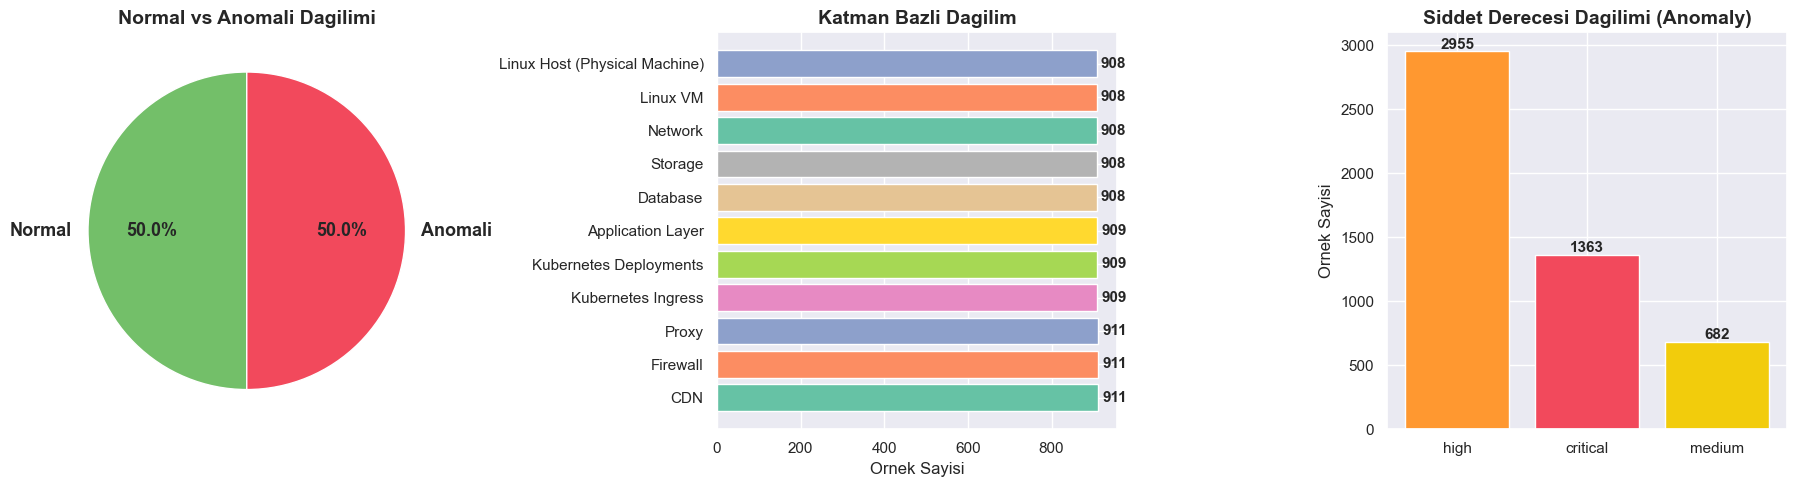

In [19]:
# Normal vs Anomali dagilim - pasta grafik
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# 1. Normal vs Anomaly
counts = metadata['is_anomaly'].value_counts()
colors = ['#73bf69', '#f2495c']
axes[0].pie(counts, labels=['Normal', 'Anomali'], autopct='%1.1f%%',
           colors=colors, startangle=90, textprops={'fontsize': 13, 'fontweight': 'bold'})
axes[0].set_title('Normal vs Anomali Dagilimi', fontsize=14, fontweight='bold')

# 2. Katman dagilimi
layer_counts = metadata['layer_name'].value_counts()
axes[1].barh(layer_counts.index, layer_counts.values, color=sns.color_palette('Set2', len(layer_counts)))
axes[1].set_xlabel('Ornek Sayisi')
axes[1].set_title('Katman Bazli Dagilim', fontsize=14, fontweight='bold')
for i, v in enumerate(layer_counts.values):
    axes[1].text(v + 10, i, str(v), va='center', fontweight='bold')

# 3. Severity dagilimi (sadece anomali)
anomaly_df = metadata[metadata['is_anomaly'] == 1]
sev_counts = anomaly_df['severity'].value_counts()
sev_colors = {'critical': '#f2495c', 'high': '#ff9830', 'medium': '#f2cc0c'}
axes[2].bar(sev_counts.index, sev_counts.values,
           color=[sev_colors.get(s, '#5794f2') for s in sev_counts.index])
axes[2].set_ylabel('Ornek Sayisi')
axes[2].set_title('Siddet Derecesi Dagilimi (Anomaly)', fontsize=14, fontweight='bold')
for i, v in enumerate(sev_counts.values):
    axes[2].text(i, v + 20, str(v), ha='center', fontweight='bold')

plt.tight_layout()
plt.show()

In [20]:
# Katman x Anomali capraz tablo
ct = pd.crosstab(metadata['layer_name'], metadata['is_anomaly'], margins=True)
ct.columns = ['Normal', 'Anomali', 'Toplam']
ct

,Normal,Anomali,Toplam
layer_name,,,
Application Layer,455,454,909
CDN,455,456,911
Database,454,454,908
Firewall,455,456,911
Kubernetes Deployments,455,454,909
Kubernetes Ingress,455,454,909
Linux Host (Physical Machine),454,454,908
Linux VM,454,454,908
Network,454,454,908


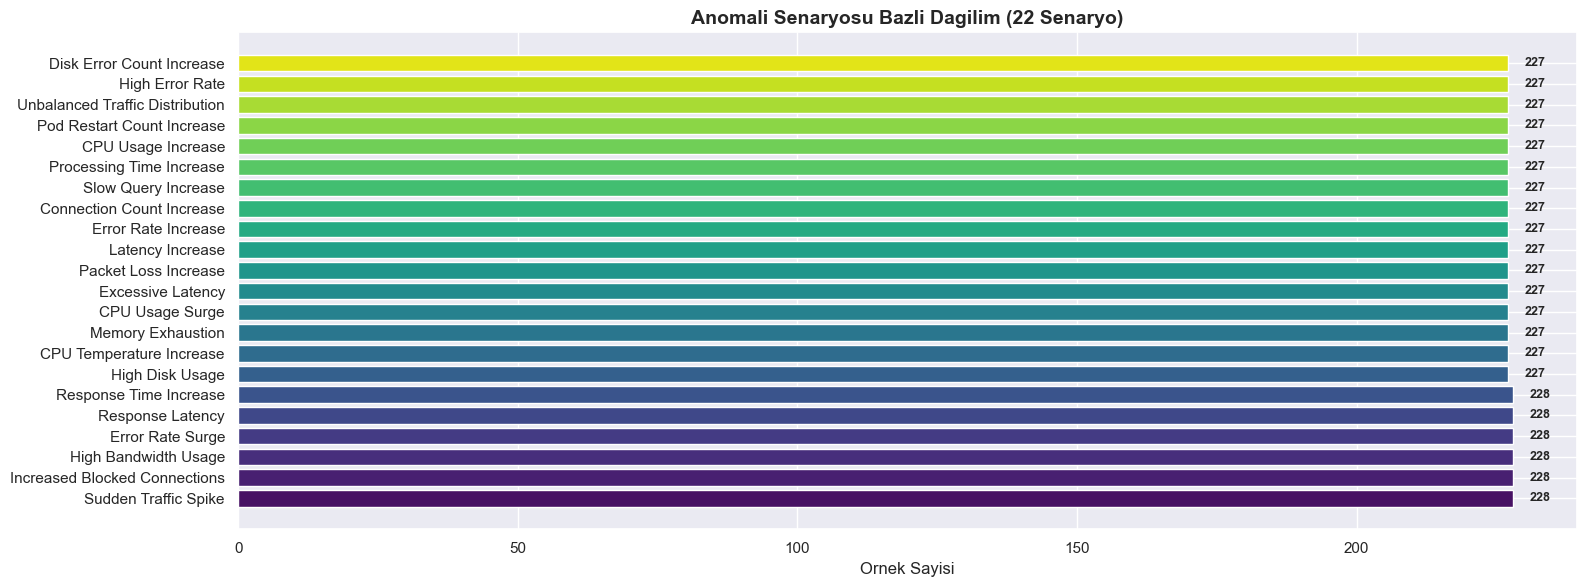

In [21]:
# Senaryo dagilimi - sadece anomali ornekleri
fig, ax = plt.subplots(figsize=(16, 6))
scenario_counts = anomaly_df['scenario_name'].value_counts()
bars = ax.barh(scenario_counts.index, scenario_counts.values, color=sns.color_palette('viridis', len(scenario_counts)))
ax.set_xlabel('Ornek Sayisi', fontsize=12)
ax.set_title('Anomali Senaryosu Bazli Dagilim (22 Senaryo)', fontsize=14, fontweight='bold')
for i, v in enumerate(scenario_counts.values):
    ax.text(v + 3, i, str(v), va='center', fontweight='bold', fontsize=9)
plt.tight_layout()
plt.show()

---
## 2 - Ornek Log Dosyalarinin Incelenmesi

In [22]:
# Normal bir log ornegi
normal_sample = metadata[metadata['is_anomaly'] == 0].iloc[0]
print(f'=== NORMAL LOG ORNEGI ===')
print(f'Sample ID: {normal_sample["sample_id"]}')
print(f'Katman: {normal_sample["layer_name"]}')
print('-'*80)
with open(DATASET_DIR / normal_sample['log_path'], 'r', encoding='utf-8') as f:
    lines = f.readlines()
for line in lines[:15]:
    print(line.strip())
print(f'... ({len(lines)} satir toplam)')

=== NORMAL LOG ORNEGI ===
Sample ID: sample_000001
Katman: CDN
--------------------------------------------------------------------------------
2026-03-05 00:00:00.604 [ERROR   ] [CDN         ] Connection to origin origin-2.us.cloud failed: 429 Internal server error
2026-03-05 00:00:55.223 [INFO    ] [CDN         ] CDN edge node edge-eu-west-8 served request for /api/v2/orders in 378ms (cache: HIT)
2026-03-05 00:01:00.574 [INFO    ] [CDN         ] CDN edge node edge-us-east-19 served request for /api/v1/search in 17ms (cache: HIT)
2026-03-05 00:01:18.429 [WARN    ] [CDN         ] Stale content served for /static/js/app.js, origin unreachable for 896s
2026-03-05 00:01:56.828 [INFO    ] [CDN         ] Traffic routed to origin origin-4.ap.cloud for path /api/v1/users, ttl=86400s
2026-03-05 00:09:20.163 [INFO    ] [CDN         ] Bandwidth allocation updated for zone zone-b5: 959Mbps
2026-03-05 00:09:00.159 [INFO    ] [CDN         ] Traffic routed to origin origin-4.eu.cloud for path /api/v

In [23]:
# Anomali log ornegi
anomaly_sample = metadata[metadata['is_anomaly'] == 1].iloc[5]
print(f'=== ANOMALI LOG ORNEGI ===')
print(f'Sample ID: {anomaly_sample["sample_id"]}')
print(f'Katman: {anomaly_sample["layer_name"]}')
print(f'Senaryo: {anomaly_sample["scenario_name"]}')
print(f'Siddet: {anomaly_sample["severity"]}')
print('-'*80)
with open(DATASET_DIR / anomaly_sample['log_path'], 'r', encoding='utf-8') as f:
    lines = f.readlines()
for line in lines[:20]:
    print(line.strip())
print(f'... ({len(lines)} satir toplam)')

=== ANOMALI LOG ORNEGI ===
Sample ID: sample_005006
Katman: CDN
Senaryo: Sudden Traffic Spike
Siddet: critical
--------------------------------------------------------------------------------
2026-03-19 19:00:00.949 [WARN    ] [CDN         ] Origin server origin-4.us.cloud response time degraded: 91ms
2026-03-19 19:01:02.948 [ERROR   ] [CDN         ] Cache corruption detected on node edge-us-west-17, initiating rebuild for zone zone-c4
2026-03-19 19:02:08.998 [CRITICAL] [CDN         ] CDN edge node edge-ap-south-11 UNRESPONSIVE — failover to edge-backup-3 initiated
2026-03-19 19:02:12.738 [INFO    ] [CDN         ] CDN edge node edge-ap-south-10 served request for /static/js/app.js in 300ms (cache: MISS)
2026-03-19 19:00:36.255 [WARN    ] [CDN         ] CDN edge node edge-us-east-3 approaching connection limit: 2784/100
2026-03-19 19:08:35.248 [INFO    ] [CDN         ] Traffic routed to origin origin-10.ap.cloud for path /health, ttl=300s
2026-03-19 19:09:12.129 [INFO    ] [CDN         

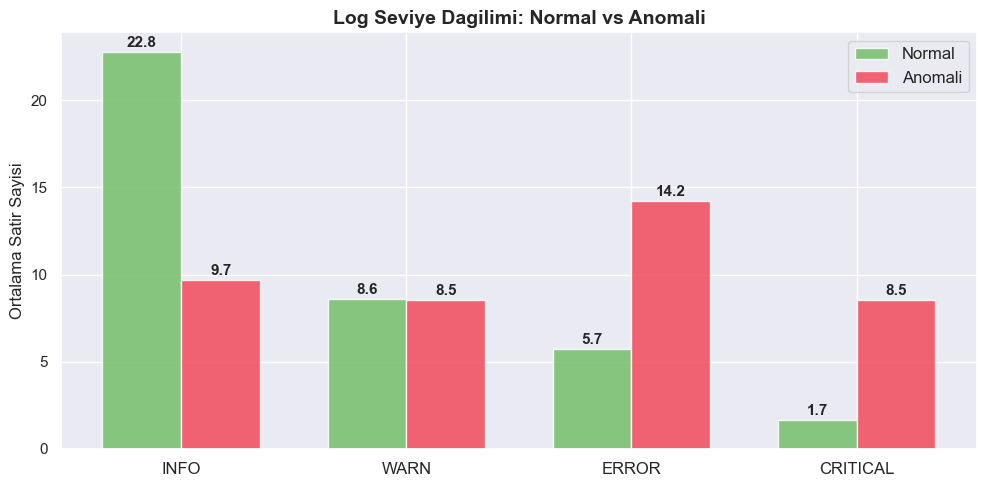

In [24]:
# Log seviye dagilimi karsilastirmasi (Normal vs Anomaly)
def count_log_levels(filepath):
    with open(filepath, 'r', encoding='utf-8') as f:
        text = f.read()
    return {
        'INFO': text.count('[INFO'),
        'WARN': text.count('[WARN'),
        'ERROR': text.count('[ERROR'),
        'CRITICAL': text.count('[CRITICAL')
    }

# 50 normal vs 50 anomaly ornekleri
normal_levels = [count_log_levels(DATASET_DIR / r['log_path']) for _, r in metadata[metadata['is_anomaly']==0].head(50).iterrows()]
anomaly_levels = [count_log_levels(DATASET_DIR / r['log_path']) for _, r in metadata[metadata['is_anomaly']==1].head(50).iterrows()]

normal_avg = pd.DataFrame(normal_levels).mean()
anomaly_avg = pd.DataFrame(anomaly_levels).mean()

fig, ax = plt.subplots(figsize=(10, 5))
x = np.arange(4)
w = 0.35
bars1 = ax.bar(x - w/2, normal_avg, w, label='Normal', color='#73bf69', alpha=0.85)
bars2 = ax.bar(x + w/2, anomaly_avg, w, label='Anomali', color='#f2495c', alpha=0.85)
ax.set_xticks(x)
ax.set_xticklabels(['INFO', 'WARN', 'ERROR', 'CRITICAL'], fontsize=12)
ax.set_ylabel('Ortalama Satir Sayisi', fontsize=12)
ax.set_title('Log Seviye Dagilimi: Normal vs Anomali', fontsize=14, fontweight='bold')
ax.legend(fontsize=12)

for bar in bars1:
    ax.text(bar.get_x() + bar.get_width()/2., bar.get_height() + 0.3,
            f'{bar.get_height():.1f}', ha='center', fontweight='bold')
for bar in bars2:
    ax.text(bar.get_x() + bar.get_width()/2., bar.get_height() + 0.3,
            f'{bar.get_height():.1f}', ha='center', fontweight='bold')

plt.tight_layout()
plt.show()

---
## 3 - Metrik Zaman Serilerinin Gorsellestirilmesi

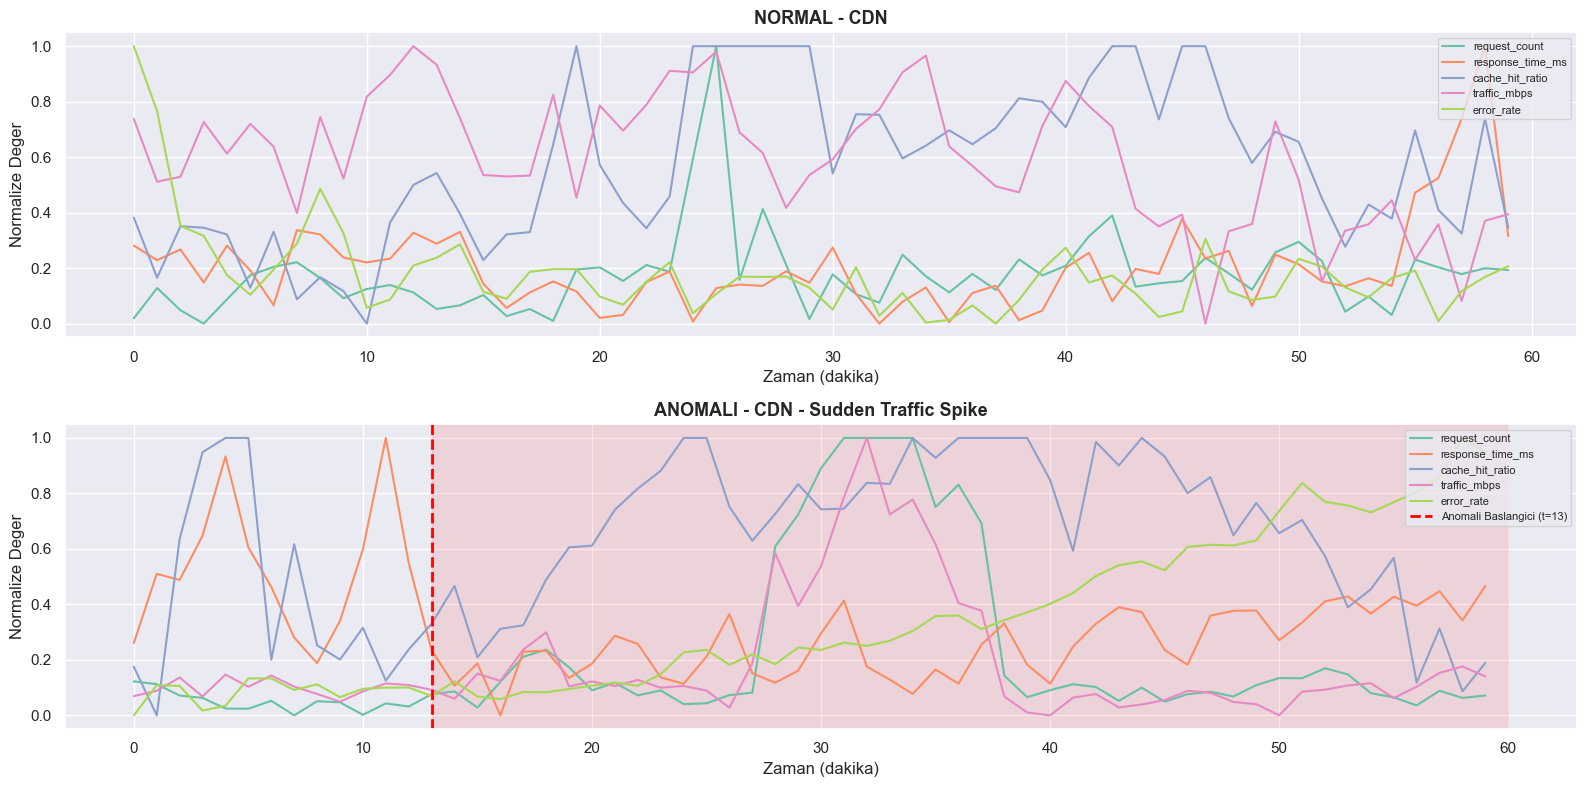

In [25]:
# Normal vs Anomaly metrik karsilastirmasi
fig, axes = plt.subplots(2, 1, figsize=(16, 8))

# Normal ornek
normal_row = metadata[metadata['is_anomaly'] == 0].iloc[10]
df_normal = pd.read_csv(DATASET_DIR / normal_row['metrics_path'])
metric_cols = [c for c in df_normal.columns if c != 'timestamp']

for col in metric_cols:
    vals = df_normal[col].values
    vals_norm = (vals - vals.min()) / (vals.max() - vals.min() + 1e-8)
    axes[0].plot(vals_norm, label=col, linewidth=1.5)

axes[0].set_title(f'NORMAL - {normal_row["layer_name"]}', fontsize=13, fontweight='bold')
axes[0].legend(loc='upper right', fontsize=8)
axes[0].set_ylabel('Normalize Deger')
axes[0].set_xlabel('Zaman (dakika)')

# Anomaly ornek
anomaly_row = metadata[metadata['is_anomaly'] == 1].iloc[10]
df_anomaly = pd.read_csv(DATASET_DIR / anomaly_row['metrics_path'])
metric_cols = [c for c in df_anomaly.columns if c != 'timestamp']

# Etiket bilgisinden anomaly_start_idx al
label = json.load(open(DATASET_DIR / anomaly_row['label_path'], 'r', encoding='utf-8'))
start_idx = label.get('anomaly_start_idx', 30)

for col in metric_cols:
    vals = df_anomaly[col].values
    vals_norm = (vals - vals.min()) / (vals.max() - vals.min() + 1e-8)
    axes[1].plot(vals_norm, label=col, linewidth=1.5)

axes[1].axvline(start_idx, color='red', linestyle='--', linewidth=2, label=f'Anomali Baslangici (t={start_idx})')
axes[1].axvspan(start_idx, len(df_anomaly), alpha=0.1, color='red')
axes[1].set_title(f'ANOMALI - {anomaly_row["layer_name"]} - {anomaly_row["scenario_name"]}',
                  fontsize=13, fontweight='bold')
axes[1].legend(loc='upper right', fontsize=8)
axes[1].set_ylabel('Normalize Deger')
axes[1].set_xlabel('Zaman (dakika)')

plt.tight_layout()
plt.show()

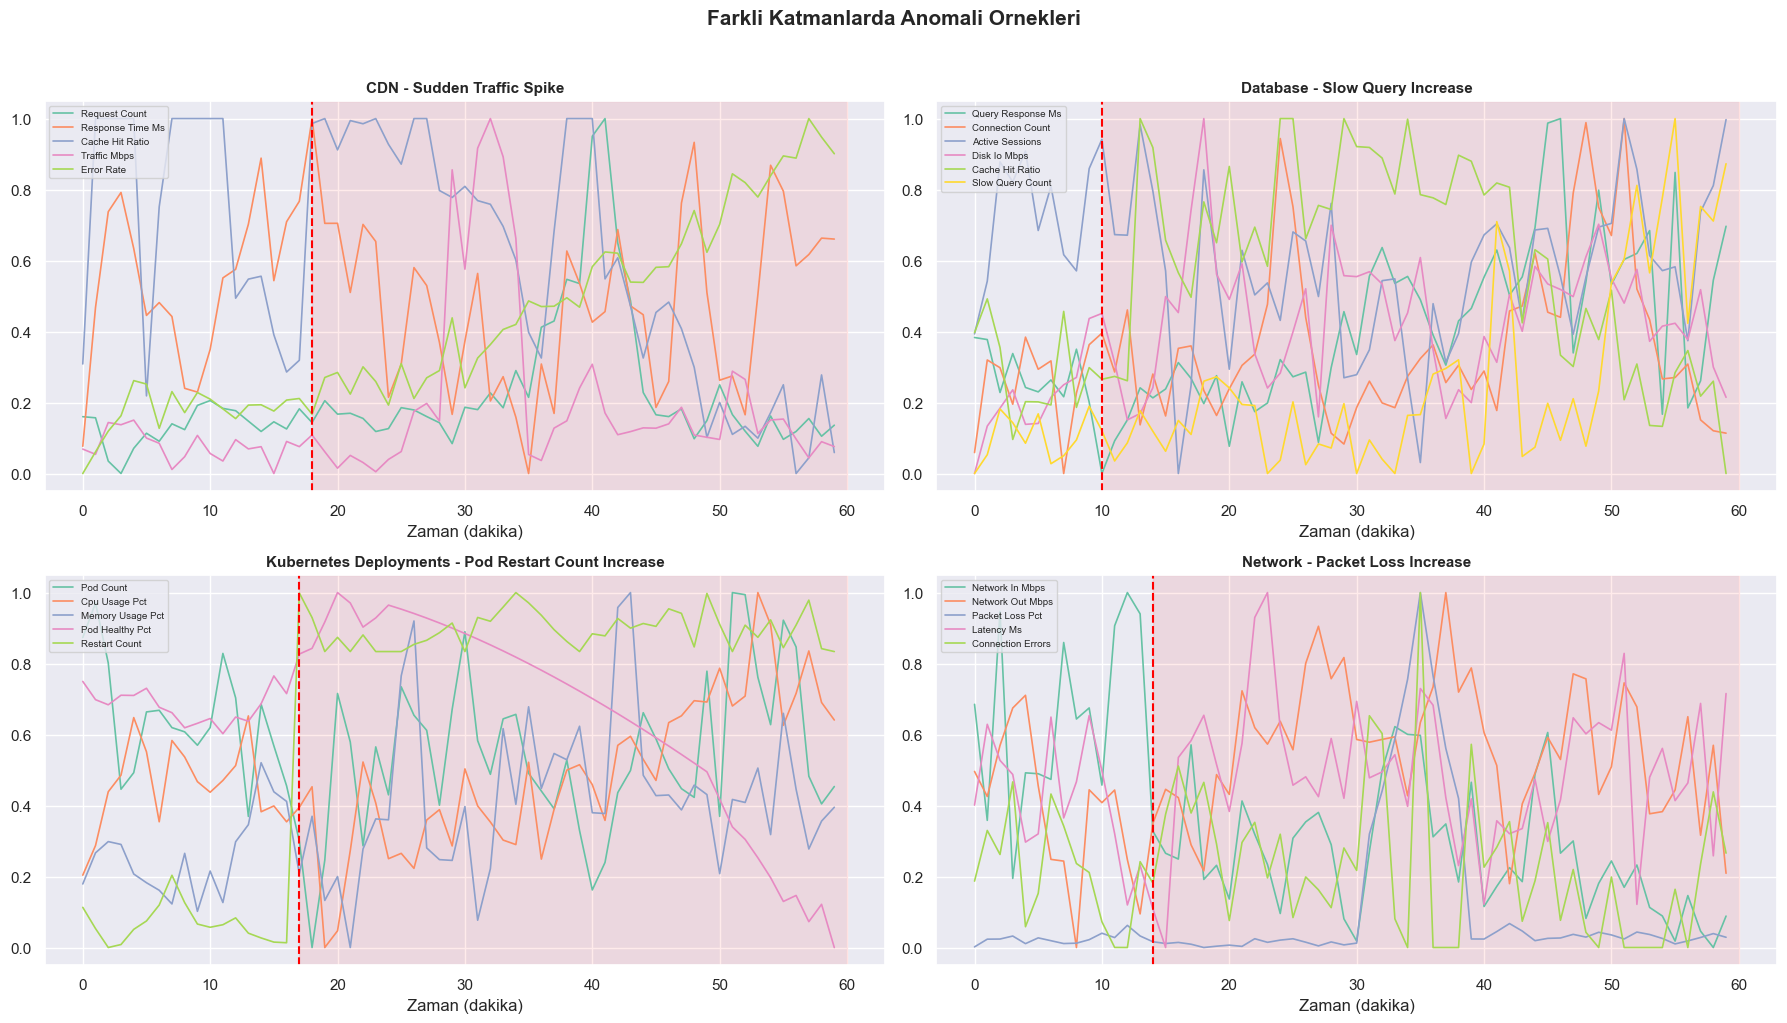

In [26]:
# Farkli katmanlardan anomali ornekleri
layers_to_show = ['cdn', 'database', 'kubernetes_deployments', 'network']
fig, axes = plt.subplots(2, 2, figsize=(18, 10))

for idx, layer in enumerate(layers_to_show):
    ax = axes[idx // 2][idx % 2]
    row = metadata[(metadata['is_anomaly'] == 1) & (metadata['layer'] == layer)].iloc[0]
    df = pd.read_csv(DATASET_DIR / row['metrics_path'])
    label = json.load(open(DATASET_DIR / row['label_path'], 'r', encoding='utf-8'))
    start_idx = label.get('anomaly_start_idx', 30)

    metric_cols = [c for c in df.columns if c != 'timestamp']
    for col in metric_cols:
        vals = df[col].values
        vals_norm = (vals - vals.min()) / (vals.max() - vals.min() + 1e-8)
        ax.plot(vals_norm, label=col.replace('_', ' ').title(), linewidth=1.2)

    ax.axvline(start_idx, color='red', linestyle='--', linewidth=1.5)
    ax.axvspan(start_idx, len(df), alpha=0.08, color='red')
    ax.set_title(f"{row['layer_name']} - {row['scenario_name']}", fontsize=11, fontweight='bold')
    ax.legend(fontsize=7, loc='upper left')
    ax.set_xlabel('Zaman (dakika)')

plt.suptitle('Farkli Katmanlarda Anomali Ornekleri', fontsize=15, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

---
## 4 - Dashboard Goruntuleri

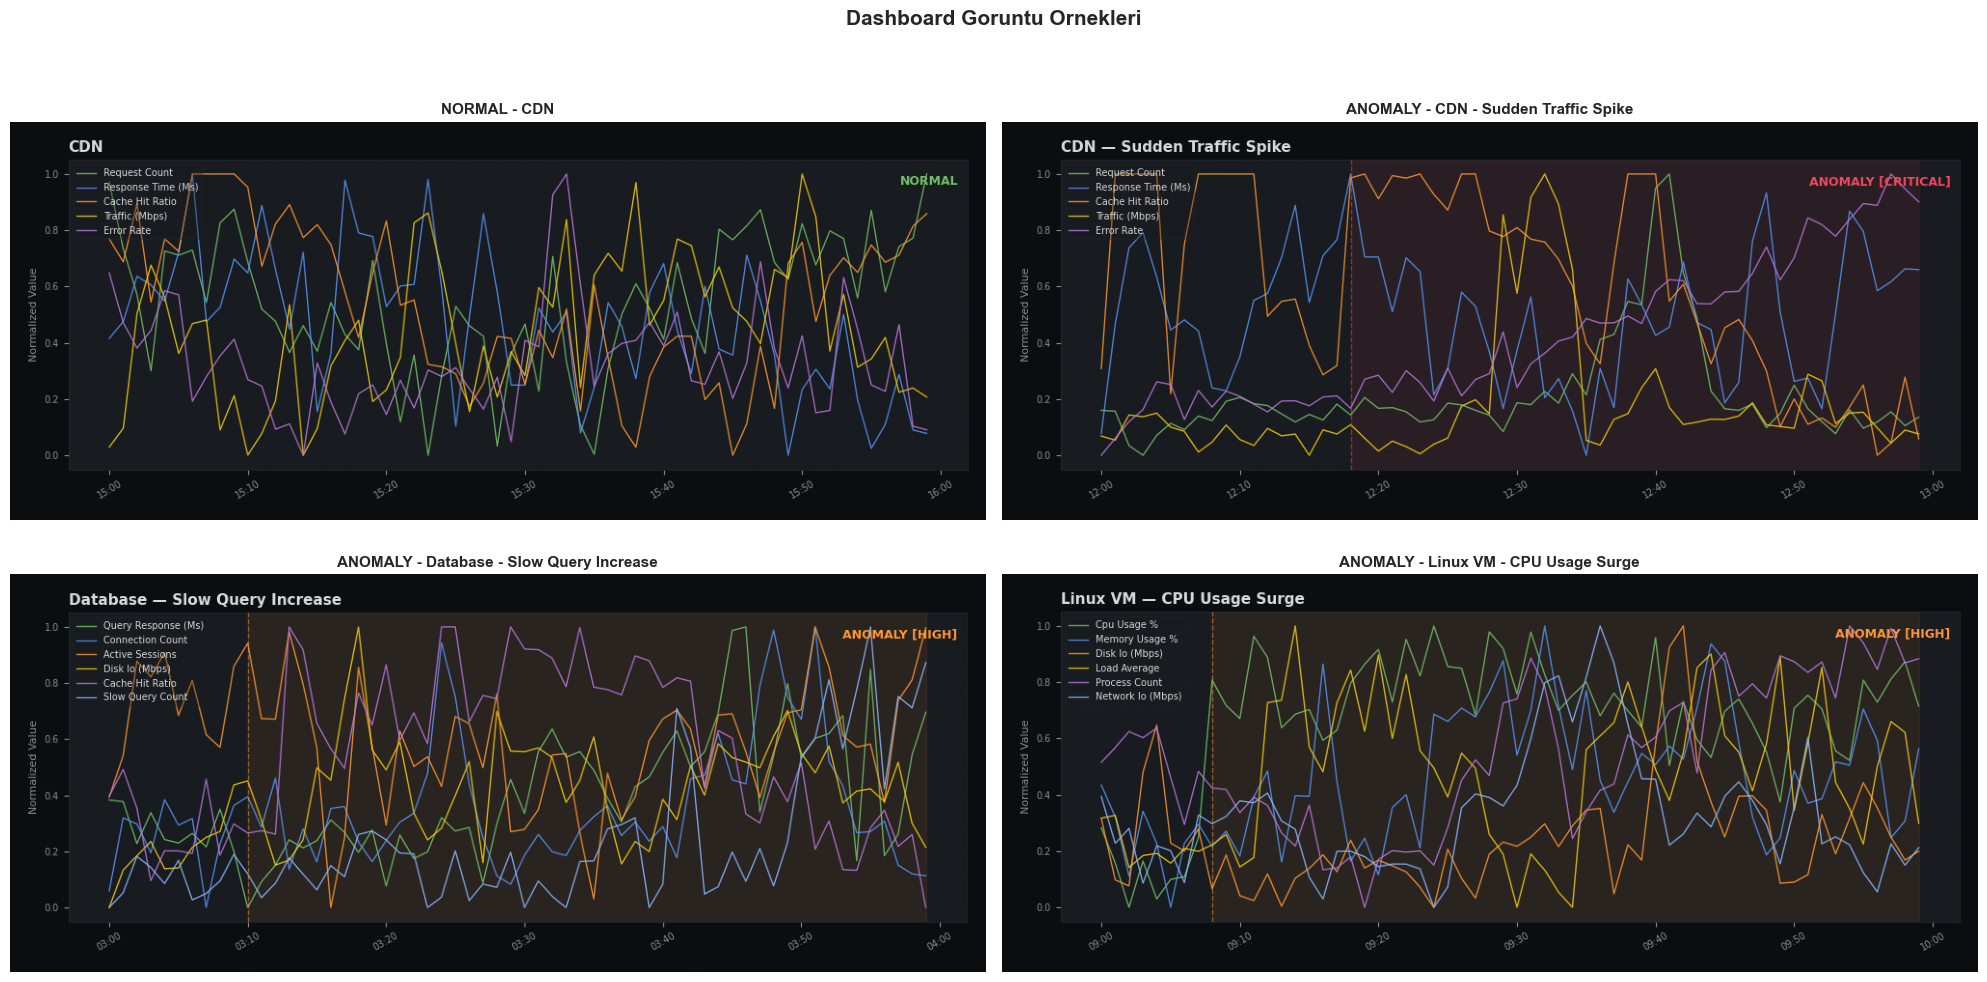

In [27]:
# 4 farkli dashboard goruntusu
fig, axes = plt.subplots(2, 2, figsize=(20, 10))

samples = [
    metadata[metadata['is_anomaly'] == 0].iloc[0],
    metadata[(metadata['is_anomaly'] == 1) & (metadata['layer'] == 'cdn')].iloc[0],
    metadata[(metadata['is_anomaly'] == 1) & (metadata['layer'] == 'database')].iloc[0],
    metadata[(metadata['is_anomaly'] == 1) & (metadata['layer'] == 'linux_vm')].iloc[0],
]

for idx, row in enumerate(samples):
    ax = axes[idx // 2][idx % 2]
    img_path = DATASET_DIR / row['dashboard_path']
    img = mpimg.imread(str(img_path))
    ax.imshow(img)
    ax.axis('off')
    status = 'ANOMALY' if row['is_anomaly'] else 'NORMAL'
    title = f"{status} - {row['layer_name']}"
    if row['is_anomaly']:
        title += f" - {row['scenario_name']}"
    ax.set_title(title, fontsize=11, fontweight='bold')

plt.suptitle('Dashboard Goruntu Ornekleri', fontsize=15, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

---
## 5 - Etiket Yapisi Analizi

In [28]:
# Ornek etiket dosyasi
sample_row = metadata[metadata['is_anomaly'] == 1].iloc[0]
label = json.load(open(DATASET_DIR / sample_row['label_path'], 'r', encoding='utf-8'))
print('=== Ornek Etiket Dosyasi ===')
print(json.dumps(label, indent=2, ensure_ascii=False))

=== Ornek Etiket Dosyasi ===
{
  "sample_id": "sample_005001",
  "layer": "cdn",
  "layer_name": "CDN",
  "is_anomaly": true,
  "scenario_id": "CDN_001",
  "scenario_name": "Sudden Traffic Spike",
  "root_cause": "Potential DDoS attack or temporary spike",
  "root_cause_category": "network",
  "severity": "critical",
  "remediation": [
    "Apply IP restrictions on firewall",
    "Trigger rate limiting script on CDN"
  ],
  "anomaly_start_idx": 18,
  "num_log_lines": 21,
  "num_metric_points": 60,
  "metrics": [
    "request_count",
    "response_time_ms",
    "cache_hit_ratio",
    "traffic_mbps",
    "error_rate"
  ],
  "timestamp_start": "2026-03-18 12:00:00",
  "timestamp_end": "2026-03-18 12:59:00"
}


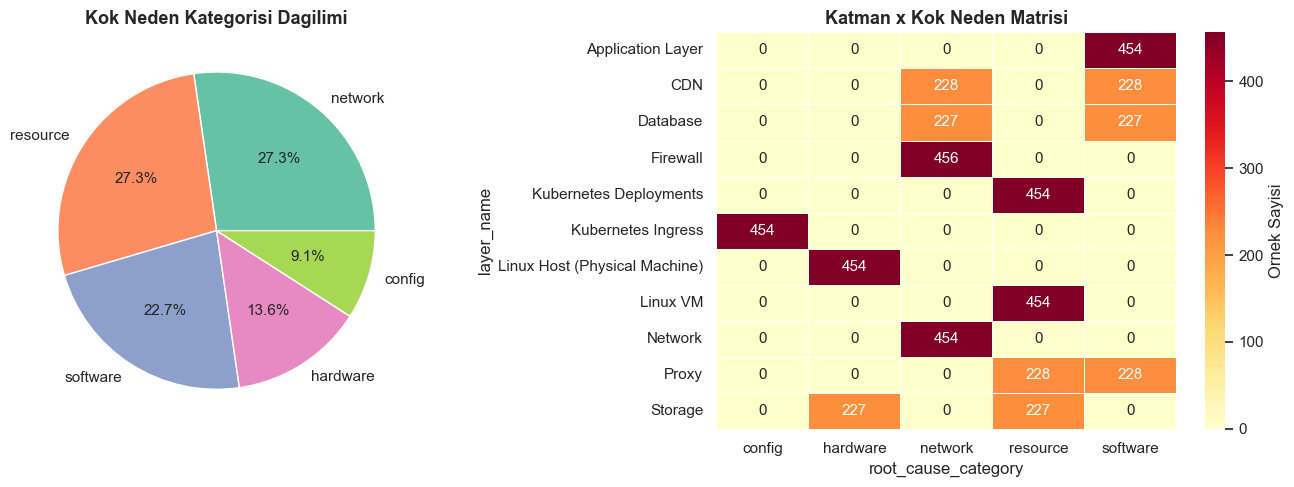

In [29]:
# Kok neden kategorisi dagilimi
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Root cause
rc_counts = anomaly_df['root_cause_category'].value_counts()
axes[0].pie(rc_counts, labels=rc_counts.index, autopct='%1.1f%%',
           colors=sns.color_palette('Set2', len(rc_counts)),
           textprops={'fontsize': 11})
axes[0].set_title('Kok Neden Kategorisi Dagilimi', fontsize=13, fontweight='bold')

# Katman x Kok Neden heatmap
ct = pd.crosstab(anomaly_df['layer_name'], anomaly_df['root_cause_category'])
sns.heatmap(ct, annot=True, fmt='d', cmap='YlOrRd', ax=axes[1],
           linewidths=0.5, cbar_kws={'label': 'Ornek Sayisi'})
axes[1].set_title('Katman x Kok Neden Matrisi', fontsize=13, fontweight='bold')

plt.tight_layout()
plt.show()

In [30]:
# Veri kumesi boyut ozeti
print('='*60)
print('  MULTIMODAL RCA VERI KUMESI OZETI')
print('='*60)
print(f'  Toplam Ornek:     {len(metadata):>10,}')
print(f'  Normal:           {(metadata["is_anomaly"]==0).sum():>10,}')
print(f'  Anomali:          {(metadata["is_anomaly"]==1).sum():>10,}')
print(f'  Katman Sayisi:    {metadata["layer"].nunique():>10}')
print(f'  Senaryo Sayisi:   {anomaly_df["scenario_id"].nunique():>10}')
print(f'  Kok Neden Turu:   {anomaly_df["root_cause_category"].nunique():>10}')
print(f'  Siddet Seviyesi:  {anomaly_df["severity"].nunique():>10}')
print('='*60)
print('\nVeri kumesi kesfi tamamlandi! Notebook 2 ye gecin.')

  MULTIMODAL RCA VERI KUMESI OZETI
  Toplam Ornek:         10,000
  Normal:                5,000
  Anomali:               5,000
  Katman Sayisi:            11
  Senaryo Sayisi:           22
  Kok Neden Turu:            5
  Siddet Seviyesi:           3

Veri kumesi kesfi tamamlandi! Notebook 2 ye gecin.
